<a href="https://colab.research.google.com/github/RimaSense/SmartSwipe_RS/blob/main/Submissions/252180603_Rima/SS_assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SmartSwipe — Assignment 1

**Dataset:** `transactions.csv`  
Explore the dataset on your own, find out about the different columns in the dataset.

---


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

---
## Q1 — Python Fundamentals `[10 pts]`

You are given the list `amounts` below.

1. Write a function `summarise(amounts, threshold)` that returns a **dict** with keys:
   - `above_threshold`: list of values strictly greater than `threshold`, sorted descending
   - `mean`: arithmetic mean (no libraries)
   - `count_above`: integer count
2. Call it with `threshold=500` and print the result.


In [3]:
# your code here
def summarise(amounts, threshold):
    """
    Summarizes a list of amounts based on a given threshold.
    """
    if not amounts:
        return {"above_threshold": [], "mean": 0, "count_above": 0}

    above_threshold = sorted([amount for amount in amounts if amount > threshold], reverse=True)
    mean = sum(amounts) / len(amounts)

    return {
        "above_threshold": above_threshold,
        "mean": mean,
        "count_above": len(above_threshold)
    }

github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'

df = pd.read_csv(github_url)
amounts_list = df['amount'].tolist()
result = summarise(amounts_list, 500)

print("\n--- Summary Results ---")
print(f"Total records processed: {len(amounts_list)}")
print(f"Mean amount: {result['mean']:.2f}")
print(f"Count strictly above 500: {result['count_above']}")
print(f"Amounts above threshold: {result['above_threshold']}")


--- Summary Results ---
Total records processed: 5176
Mean amount: 1253.02
Count strictly above 500: 2392
Amounts above threshold: [14205.88, 14011.64, 13184.18, 13086.34, 12304.94, 12250.73, 12199.01, 11818.92, 11772.79, 11662.54, 11471.08, 11371.61, 11234.88, 11199.06, 11195.5, 11101.87, 11073.38, 11069.15, 11007.74, 10905.49, 10864.93, 10713.45, 10491.16, 10380.89, 10359.9, 10312.18, 10252.55, 10151.58, 10150.55, 10095.57, 9796.81, 9794.37, 9783.26, 9764.67, 9716.4, 9612.35, 9608.31, 9600.26, 9593.46, 9568.04, 9492.12, 9468.63, 9421.41, 9420.5, 9416.27, 9376.75, 9323.98, 9311.32, 9244.25, 9211.58, 9126.68, 9093.21, 9051.72, 9026.74, 9016.71, 8991.0, 8891.44, 8880.77, 8858.52, 8828.05, 8807.32, 8786.62, 8769.03, 8713.76, 8698.26, 8687.37, 8678.88, 8671.19, 8657.93, 8651.19, 8649.46, 8643.98, 8628.76, 8604.56, 8600.0, 8591.48, 8535.93, 8504.49, 8465.53, 8427.74, 8426.91, 8375.23, 8358.33, 8317.36, 8290.01, 8255.59, 8217.94, 8211.15, 8191.41, 8187.97, 8173.21, 8154.55, 8151.36, 8089.0

---
## Q2 — NumPy `[15 pts]`

Load **only** the `amount` column into a NumPy array. Then:

1. Print mean, median, std, 10th and 90th percentiles.
2. Create a boolean mask for **outlier** transactions: those where `|amount − mean| > 2 × std`.
3. Normalise the array to `[0, 1]` using min-max scaling and store it as `amounts_norm`.
4. Using `np.histogram`, compute a 10-bin histogram of `amounts_norm` and print bin edges + counts (no plot needed).


In [7]:
# your code here

github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url, usecols=['amount'])
amounts = df['amount'].values

# 1. Compute and print statistics
mean_val = np.mean(amounts)
median_val = np.median(amounts)
std_val = np.std(amounts)
p10 = np.percentile(amounts, 10)
p90 = np.percentile(amounts, 90)

print("--- Statistics ---")
print(f"Mean: {mean_val:.2f}")
print(f"Median: {median_val:.2f}")
print(f"Std: {std_val:.2f}")
print(f"10th Percentile: {p10:.2f}")
print(f"90th Percentile: {p90:.2f}")

# 2. Create a boolean mask for outlier transactions (|amount - mean| > 2 * std)
outlier_mask = np.abs(amounts - mean_val) > 2 * std_val
print(f"\nNumber of outliers detected: {np.sum(outlier_mask)}")

# 3. Normalise the array to [0, 1] using min-max scaling
min_val = np.min(amounts)
max_val = np.max(amounts)
amounts_norm = (amounts - min_val) / (max_val - min_val)

# 4. Compute a 10-bin histogram of amounts_norm and print bin edges + counts
counts, bin_edges = np.histogram(amounts_norm, bins=10)

print("\n--- Histogram of Normalized Amounts ---")
print(f"Counts:    {counts}")
print(f"Bin Edges: {bin_edges}")

--- Statistics ---
Mean: 1253.02
Median: 433.38
Std: 1989.76
10th Percentile: 88.25
90th Percentile: 4024.01

Number of outliers detected: 353

--- Histogram of Normalized Amounts ---
Counts:    [4020  479  191  187  141   81   47   18    8    4]
Bin Edges: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Q3 — Pandas: Load & Explore `[15 pts]`

1. Load `smartswipe_transactions.csv` into a DataFrame `df`.
2. Print shape, dtypes, and count of missing values per column.
3. Parse `date` as `datetime` (in-place). Add a column `month` (integer, 1–12).
4. Print the statistical summary for numeric columns only.
5. How many unique `city` and `category` values exist? Print them.


In [3]:
# your code here

#1
github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url)

#2
print("--- Shape ---")
print(df.shape)
print("\n--- Data Types ---")
print(df.dtypes)
print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

#3
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

#4
print("\n--- Statistical Summary (Numeric Columns Only) ---")
print(df.describe(include=['number']))

#5
print("\n--- Unique Cities ---")
print(f"Count: {df['city'].nunique()}")
print(f"Values: {df['city'].unique()}")

print("\n--- Unique Categories ---")
print(f"Count: {df['category'].nunique()}")
print(f"Values: {df['category'].unique()}")

--- Shape ---
(5176, 9)

--- Data Types ---
txn_id       object
user_id      object
merchant     object
category     object
amount      float64
datetime     object
city         object
cashback    float64
status       object
dtype: object

--- Missing Values Per Column ---
txn_id        0
user_id       0
merchant      0
category      0
amount        0
datetime      0
city          0
cashback    258
status        0
dtype: int64

--- Statistical Summary (Numeric Columns Only) ---
             amount     cashback        month
count   5176.000000  4918.000000  5176.000000
mean    1253.022884    29.513211     3.455564
std     1989.949158    87.547840     1.678726
min       10.000000     0.000000     1.000000
25%      173.882500     1.070000     2.000000
50%      433.385000     6.565000     3.000000
75%     1251.317500    21.355000     5.000000
max    14205.880000  2440.530000     6.000000

--- Unique Cities ---
Count: 9
Values: ['Delhi' 'Hyderabad' 'Chennai' 'Mumbai' 'Jaipur' 'Pune' 'Kanpur'

---
## Q4 — Pandas: Filter & Transform `[20 pts]`

1. Filter to **approved** transactions only. What fraction of total transactions is this? Print as a percentage.
2. Add column `cashback_rate` = `cashback / amount`. Flag rows where this exceeds 0.10 as `suspicious` (boolean column).
3. Fill any missing `cashback` values with the **per-category median** cashback (do not use a global fill).
4. Create a `spend_tier` column: `low` (amount < 500), `mid` (500–2000), `high` (> 2000).
   Use `pd.cut` — do not write if-else chains.


In [4]:
# your code here

github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url)

#1
total_transactions = len(df)
df = df[df['status'] == 'approved'].copy()  # Overwrite df to keep only approved
approved_percentage = (len(df) / total_transactions) * 100
print(f"Percentage of approved transactions: {approved_percentage:.2f}%")

#2
df['cashback_rate'] = df['cashback'] / df['amount']
df['suspicious'] = df['cashback_rate'] > 0.10

#3
# We use groupby and transform to apply the median of each specific category
df['cashback'] = df.groupby('category')['cashback'].transform(lambda x: x.fillna(x.median()))


#4
#setting right=False means the lower bound is inclusive and the upper bound is exclusive
df['spend_tier'] = pd.cut(
    df['amount'],
    bins=[0, 500, 2000, float('inf')],
    labels=['low', 'mid', 'high'],
    right=False
)

# Print summary
print(f"Number of suspicious transactions detected: {df['suspicious'].sum()}")
print("\nSpend Tiers Count:")
print(df['spend_tier'].value_counts())

Percentage of approved transactions: 88.97%
Number of suspicious transactions detected: 185

Spend Tiers Count:
spend_tier
low     2666
mid     1378
high     561
Name: count, dtype: int64


---
## Q5 — Pandas: Aggregation `[20 pts]`

1. For each `category`, compute: total spend, transaction count, avg transaction size, decline rate.
   Store as a clean DataFrame `category_stats` and print it sorted by total spend descending.
2. Find the **top-3 merchants** by total spend within each city. Output should be a DataFrame with columns `city`, `merchant`, `total_spend`.
3. Build a **month × category pivot table** of average transaction amounts. Print it.


In [5]:
# your code here

github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url)
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

#1
# Create a boolean series to calculate the proportion of declined transactions
df['is_declined'] = df['status'] == 'declined'

category_stats = df.groupby('category').agg(
    total_spend=('amount', 'sum'),
    transaction_count=('amount', 'count'),
    avg_transaction_size=('amount', 'mean'),
    decline_rate=('is_declined', 'mean')
).reset_index()

# Sort by total spend descending
category_stats = category_stats.sort_values(by='total_spend', ascending=False)
print("---  Category Stats ---")
print(category_stats.to_string(index=False))


#2
city_merchant_spend = df.groupby(['city', 'merchant'])['amount'].sum().reset_index(name='total_spend')

# Sort to ensure highest spend is at the top for each city, then group and take head(3)
top_3_merchants = city_merchant_spend.sort_values(['city', 'total_spend'], ascending=[True, False])
top_3_merchants = top_3_merchants.groupby('city').head(3).reset_index(drop=True)

print("\n--- Top-3 Merchants by City ---")
print(top_3_merchants.to_string(index=False))

#3
pivot_df = pd.pivot_table(
    df,
    values='amount',
    index='month',
    columns='category',
    aggfunc='mean'
)

print("\n---  Month x Category Pivot Table (Avg Transaction Amounts) ---")
print(pivot_df.round(2).to_string())

---  Category Stats ---
     category  total_spend  transaction_count  avg_transaction_size  decline_rate
       Travel   2213273.63                444           4984.850518      0.340090
  Electronics   1722710.26                384           4486.224635      0.377604
     Shopping   1031848.97                651           1585.021459      0.188940
   Healthcare    438697.56                420           1044.518000      0.061905
       Dining    371893.93                768            484.236888      0.045573
    Utilities    290547.44                390            744.993436      0.046154
    Groceries    195293.44                905            215.793856      0.049724
Entertainment    153913.21                527            292.055427      0.037951
         Fuel     67468.01                687             98.206710      0.011645

--- Top-3 Merchants by City ---
     city      merchant  total_spend
Bangalore   Apple Store     96407.84
Bangalore         IRCTC     89028.77
Bangalore   

---
## Q6 — Matplotlib: Visualisation `[20 pts]`

Produce a single `fig` with **3 subplots** (layout your choice):

1. **Bar chart** — Total spend per category. Sort bars descending. Label axes.
2. **Line chart** — Daily total spend over time. Use `date` on x-axis. Rotate tick labels 45°.
3. **Histogram** — Distribution of `amount` for approved vs declined transactions overlaid (use `alpha=0.6`). Add a legend.

Titles, axis labels, and `fig.tight_layout()` are required.


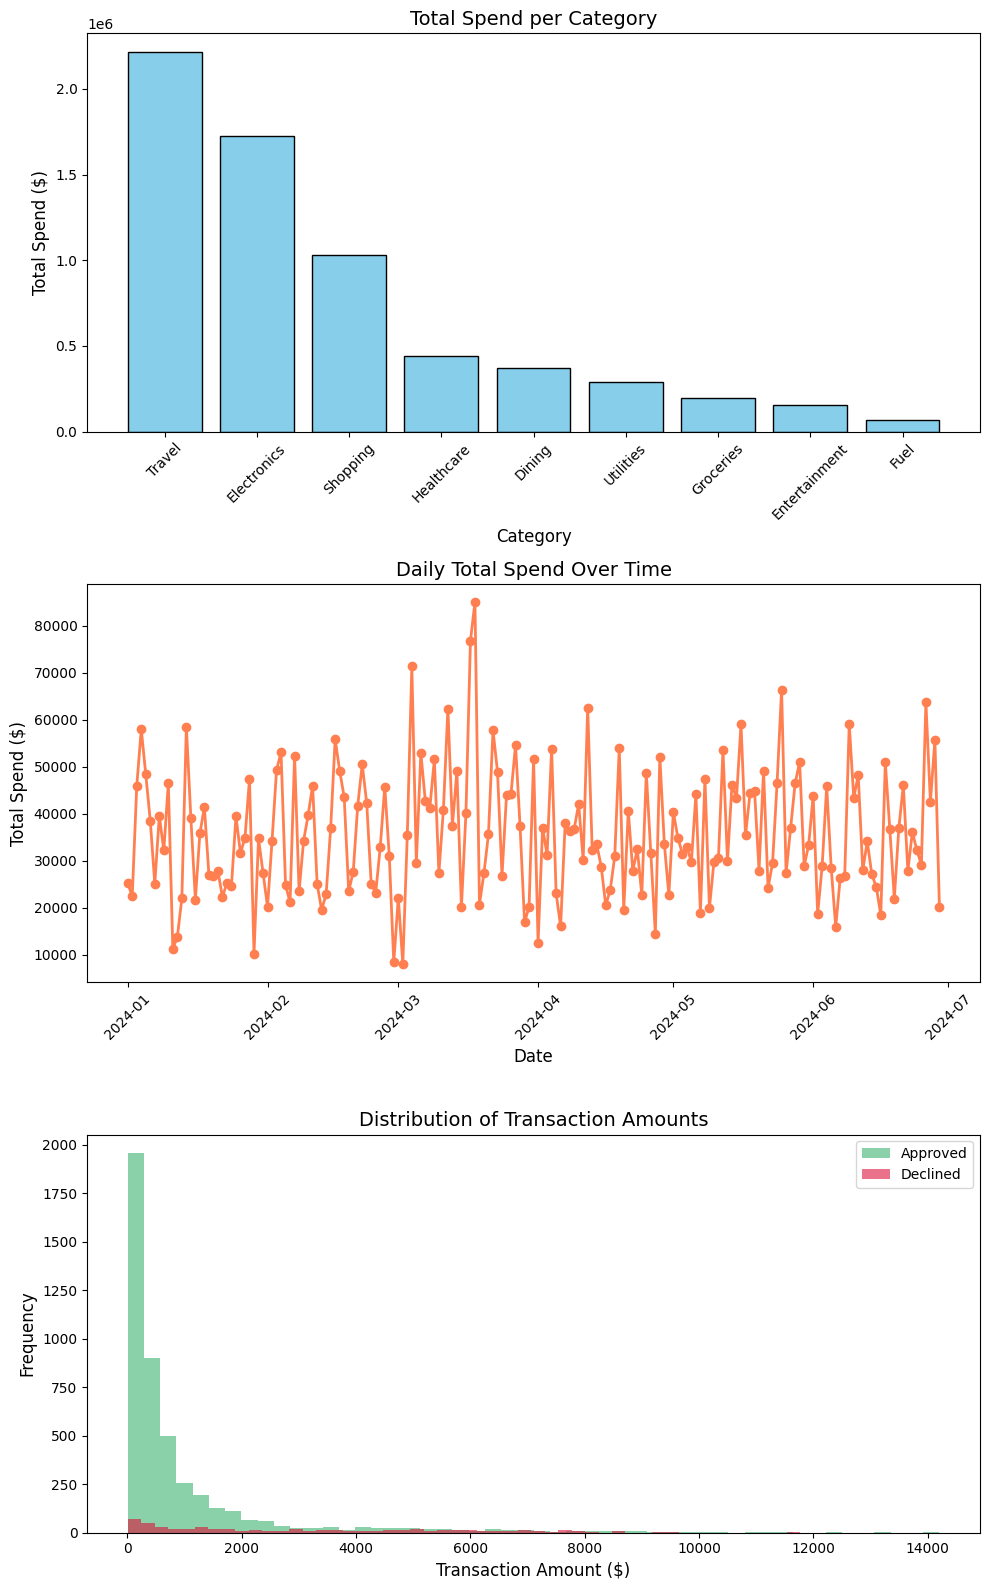

In [7]:
# your code here

github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url)

# Ensure datetime is correctly parsed and extract just the date for the line chart
df['datetime'] = pd.to_datetime(df['datetime'])
df['date_only'] = df['datetime'].dt.date

# Create the figure and axes (3 rows, 1 column)
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 16))

# Subplot 1: Bar chart — Total spend per category
# Calculate total spend and sort descending
cat_spend = df.groupby('category')['amount'].sum().sort_values(ascending=False)

axes[0].bar(cat_spend.index, cat_spend.values, color='skyblue', edgecolor='black')
axes[0].set_title('Total Spend per Category', fontsize=14)
axes[0].set_xlabel('Category', fontsize=12)
axes[0].set_ylabel('Total Spend ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Subplot 2: Line chart — Daily total spend over time
# Group by the date we extracted earlier
daily_spend = df.groupby('date_only')['amount'].sum()

axes[1].plot(daily_spend.index, daily_spend.values, marker='o', color='coral', linewidth=2)
axes[1].set_title('Daily Total Spend Over Time', fontsize=14)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Total Spend ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Subplot 3: Histogram — Amount distribution (Overlaid)
# Separate amounts based on status (handling potential case sensitivity)
approved_amt = df[df['status'].str.lower() == 'approved']['amount']
declined_amt = df[df['status'].str.lower() == 'declined']['amount']

# Plot both histograms on the same axes with alpha=0.6 for transparency
axes[2].hist(approved_amt, bins=50, alpha=0.6, label='Approved', color='mediumseagreen')
axes[2].hist(declined_amt, bins=50, alpha=0.6, label='Declined', color='crimson')

axes[2].set_title('Distribution of Transaction Amounts', fontsize=14)
axes[2].set_xlabel('Transaction Amount ($)', fontsize=12)
axes[2].set_ylabel('Frequency', fontsize=12)
axes[2].legend()

# Final Layout Adjustments
# Apply tight_layout to automatically fix spacing issues between subplots
fig.tight_layout()

# Display the plot
plt.show()

---
## Q7 — Bonus `[30 pts]`

> This question is intentionally hard. Not compulsory.

**SmartSwipe Velocity Fraud Detector**

A transaction is part of a **velocity fraud event** if a single `user_id` has **≥ 3 transactions within any rolling 1-hour window**.

Date and Time are available in the CSV.

Tasks:

1. Write a function `flag_velocity_fraud(df, window='1h', min_txns=3)` that returns a boolean Series aligned to `df.index` — `True` if the transaction falls inside a fraud window for that user.
   - Must handle per-user sorted datetime correctly.
   - No row-wise Python loops over the full DataFrame.
2. Add column `velocity_fraud` using your function.
3. Compare flagged vs normal users on: avg spend, decline rate, top categories. Print a clean summary table.
4. Plot a **timeline scatter** (x = datetime, y = user_id, colour = velocity_fraud). Limit to 20 users for readability.


Total velocity fraud transactions flagged: 91

--- Summary Table ---
   user_type  user_count  txn_count   avg_spend  decline_rate top_category
Flagged User          16        381 2494.220157      0.498688       Travel
 Normal User         384       4795 1154.400119      0.079458    Groceries


/tmp/ipykernel_600/3766648420.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby('user_type').apply(


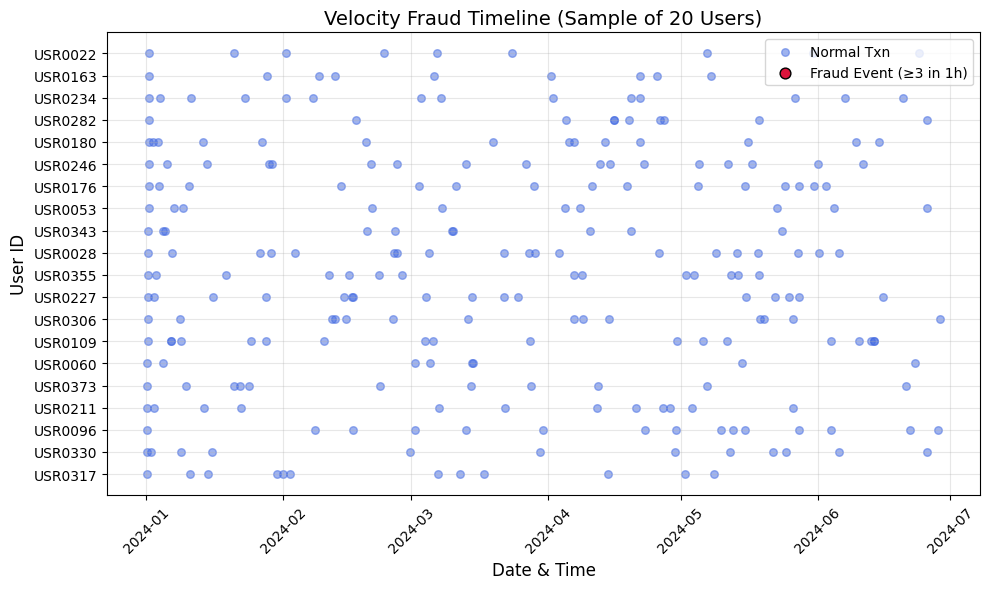

In [13]:
# your code here


github_url = 'https://raw.githubusercontent.com/RimaSense/SmartSwipe_RS/refs/heads/main/Week_0/transactions.csv'
df = pd.read_csv(github_url)
df['datetime'] = pd.to_datetime(df['datetime'])

# Define the Velocity Fraud Function
def flag_velocity_fraud(df, window='1h', min_txns=3):
    """
    Flags transactions that breach a rolling velocity threshold.
    Returns a boolean Series perfectly aligned to the original DataFrame index.
    """
    # Keep track of the original index to align perfectly at the end
    temp = df[['user_id', 'datetime']].copy()
    temp['datetime'] = pd.to_datetime(temp['datetime'])
    temp['orig_index'] = temp.index

    # Sort chronologically and set datetime as index for the rolling window
    temp = temp.sort_values('datetime').set_index('datetime')

    temp['tx_count'] = 1

    # Compute rolling count of transactions per user over the specified window
    # If the count is >= min_txns, the transaction is flagged
    temp['is_fraud'] = temp.groupby('user_id')['user_id'].transform(
        lambda x: x.rolling(window).count() >= min_txns
    )

    # Restore original index and return the boolean series
    temp = temp.set_index('orig_index')
    return temp.loc[df.index, 'is_fraud']

# 3. Add the velocity_fraud column
df['velocity_fraud'] = flag_velocity_fraud(df)
print(f"Total velocity fraud transactions flagged: {df['velocity_fraud'].sum()}")

# 4. Compare Flagged vs Normal Users
# We classify a user as 'Flagged User' if they have AT LEAST one fraud transaction
fraud_users = df[df['velocity_fraud']]['user_id'].unique()
df['user_type'] = np.where(df['user_id'].isin(fraud_users), 'Flagged User', 'Normal User')

# Create a boolean column for declined transactions to calculate the rate easily
df['is_declined'] = df['status'].str.lower() == 'declined'

# Aggregate metrics per user group
summary = df.groupby('user_type').apply(
    lambda g: pd.Series({
        'user_count': g['user_id'].nunique(),
        'txn_count': len(g),
        'avg_spend': g['amount'].mean(),
        'decline_rate': g['is_declined'].mean(),
        'top_category': g['category'].value_counts().index[0]
    })
).reset_index()

print("\n--- Summary Table ---")
print(summary.to_string(index=False))

# 5. Plot Timeline Scatter (Limited to 20 users)
subset_users = df['user_id'].unique()[:20]
subset_df = df[df['user_id'].isin(subset_users)].copy()

# Separate data for coloring
normal_pts = subset_df[~subset_df['velocity_fraud']]
fraud_pts = subset_df[subset_df['velocity_fraud']]

plt.figure(figsize=(10, 6))
plt.scatter(normal_pts['datetime'], normal_pts['user_id'],
            color='royalblue', label='Normal Txn', alpha=0.5, s=30)
plt.scatter(fraud_pts['datetime'], fraud_pts['user_id'],
            color='crimson', label='Fraud Event (≥3 in 1h)', alpha=1.0, s=60, edgecolor='black')

plt.title("Velocity Fraud Timeline (Sample of 20 Users)", fontsize=14)
plt.xlabel("Date & Time", fontsize=12)
plt.ylabel("User ID", fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
